# **Tutorial 1 (Part-I):** Rock Components Modeling

This module contain a set of classes each simulating a component of rock (such as Mineral/Fluid, MineralSet (Matrix), FluidSet and Rock). These classes wrap around different petrophysical and rock physics relations to simulate the rocks and their componets. For example, modeling a rock that follows the inclusion theory or Contact theory is done through the `InclusionRock` or `GranularRock` classs, respectively. Each of these two class consists of `MineralSet` and `FluidSet`. `MineralSet` and `FluidSet` themeselves are consist of `Mineral` and `Fluid`.

## Class `Material`
This is the base class for all other classes (or rock components) in `materials.py` module. A material object can be simply defined by three elastic parameters of P-velocity, S-velocity and density.

Note:
In all other classes and throughout the `rokpy` the three key (primary) elastic parameter are Bulk modulus (K), Shear modulus (G) and Density (rho), because most of the effective medium theories, calculate these three parameters as output. But `Material` class is an exception where instead of Bulk and Shear moduli, P- and S-wave velocities are selected as input parameter, because these are usually the available/measured parameter.

In [2]:
from rokpy.materials import Material
material = Material(p_velocity=3500, s_velocity=2000, density=2.2)
print(material)

Type                |    Density    |  P-velocity   |  S-velocity   |     Bulk      |     Shear     |    Poisson    
---------------------------------------------------------------------------------------------------------
General             |     2.200     |    3500.00    |    2000.00    |     15.22     |     8.80      |     0.258     



Objects of `Material` class (as well as all its subclasses including `Component`, `ComponentSet`, `Rock`, etc.), once generated, will automatically give you access to a bunch of other elastic properties such as bulk and shear moduli, Poisson's ratio, Lame coefficient, Young's modulus and P-to S- velocity ratio as follows:

In [3]:
#Access properties in a Material object
print(f'Density             = {material.density}')
print(f'P_velocity          = {material.p_velocity}')
print(f'S_velocity          = {material.s_velocity}')
print(f'Shear Modulus       = {material.shear}')
print(f'Bulk Modulus        = {material.bulk}')
print(f'Poisson Ratio       = {material.poisson}')
print(f'Lame Coefficient    = {material.lame}')
print(f'Young Modulus       = {material.young}')

Density             = [2.2]
P_velocity          = [3500.]
S_velocity          = [2000.]
Shear Modulus       = [8.8]
Bulk Modulus        = [15.21666667]
Poisson Ratio       = [0.25757576]
Lame Coefficient    = [9.35]
Young Modulus       = [22.13333333]


It worth noting that, all above parameters of a material object except those three input parameters are calculated on-the-fly rather than be stored in the object. Therefore, these parameters cannot be assign directly. Modifying the three input parameters (P-velocity, S-velocity and density) will automatically alter these parameters.

In [4]:
#Modify Bulk and Shear modulus:
material.p_velocity = 5500
material.s_velocity = 3000
material.density = 2.71

#Disply the material object and note how other properties are also changed.
print(material)

Type                |    Density    |  P-velocity   |  S-velocity   |     Bulk      |     Shear     |    Poisson    
---------------------------------------------------------------------------------------------------------
General             |     2.710     |    5500.00    |    3000.00    |     49.46     |     24.39     |     0.288     



## Tables of Properties
Among the rock component classes, `Mineral` and `Fluid` properties are assigned directly, while `ComponentSet` and `Rock` properties are calculated according to their effective medium models. 
`Mineral` and `Fluid` prperties may be either assigned manually or be read from available tables of properties.

`rokpy` includes several tables of constant (stored in `constant.py` module) which serves as reference tables throughout the package codes. Among them, two tables of `MineralsPropertyTable` and `FluidsPropertyTable`, as their name suggest, store the three key elastic properties (Bulk modulus, Shear modulus and Density) corresponding to different minerals anf fluids, repsectively. 
These tables may be customized through modifying the property values and adding/removing items upon the requirements.

### Table of Minerals Property
Reference (standard) elastic properties of the different mineralogies are stored in a table called `MineralsPropertyTable`. Follwing is an example showing how to instantiate a minerals propery table. 

In [5]:
from rokpy.constants import MineralsPropertyTable

#Realizing the default table as an object
minerals_table = MineralsPropertyTable()

#Printing the table will reveal its content
print(minerals_table)


General              : type: General        | rho: 0.000	| K: 0.000   | G: 0.000   | Vp: 0.00     | Vs: 0.00     
Anhydrite            : type: Anhydrite      | rho: 3.000	| K: 66.500  | G: 34.000  | Vp: 6105.55  | Vs: 3366.50  
Aragonite            : type: Aragonite      | rho: 2.940	| K: 47.000  | G: 39.000  | Vp: 5802.88  | Vs: 3642.16  
Biotite              : type: Biotite        | rho: 3.000	| K: 50.000  | G: 27.000  | Vp: 5354.13  | Vs: 3000.00  
BituminCoal          : type: BituminCoal    | rho: 1.240	| K: 4.620   | G: 2.610   | Vp: 2555.83  | Vs: 1450.81  
CaFeldspar           : type: CaFeldspar     | rho: 2.810	| K: 75.700  | G: 37.000  | Vp: 6670.52  | Vs: 3628.67  
Calcite              : type: Calcite        | rho: 2.710	| K: 63.700  | G: 31.700  | Vp: 6253.17  | Vs: 3420.15  
Chert                : type: Chert          | rho: 2.630	| K: 42.200  | G: 37.000  | Vp: 5899.45  | Vs: 3750.79  
Chlorite             : type: Chlorite       | rho: 2.760	| K: 146.250 | G: 68.150  | Vp:

Each field of these tables refers to a single mineral/fluid where its value is an `ElasticPropertySet`. The `ElasticPropertySet` is a simple container of three key elastic properties (bulk, shear and density) as well as some other auxilliary (less important) parameters.

In [6]:
#Accessing a mineral from the table
quartz = minerals_table.Quartz
print(quartz)

#Mineral properties can be accessed as attributes
print(f'Quartz Bulk Modulus : {quartz.bulk}')
print(f'Quartz Shear Modulus: {quartz.shear}')
print(f'Quartz Density      : {quartz.density}') 

type: Quartz         | rho: 2.650	| K: 36.600  | G: 45.000  | Vp: 6037.62  | Vs: 4120.82  
Quartz Bulk Modulus : 36.6
Quartz Shear Modulus: 45.0
Quartz Density      : 2.65


Users may instantiate and customize different tables upon their requirements:

In [7]:
from rokpy.constants import ElasticPropertySet

#Create a default Minerals Property Table
northsea_minerals_table = MineralsPropertyTable()

# Customize the table as needed:
# Modify some mineral
northsea_minerals_table.Calcite.bulk=68 #GPa
northsea_minerals_table.Calcite.shear=32 #GPa
# Add new custom mineral
northsea_minerals_table.add_item("till_clay", ElasticPropertySet(2.2, 28, 15))


#Mineral Properties Table as modified by user:
print(northsea_minerals_table)


till_clay            : type: Mineral        | rho: 2.200	| K: 28.000  | G: 15.000  | Vp: 4670.99  | Vs: 2611.16  
General              : type: General        | rho: 0.000	| K: 0.000   | G: 0.000   | Vp: 0.00     | Vs: 0.00     
Anhydrite            : type: Anhydrite      | rho: 3.000	| K: 66.500  | G: 34.000  | Vp: 6105.55  | Vs: 3366.50  
Aragonite            : type: Aragonite      | rho: 2.940	| K: 47.000  | G: 39.000  | Vp: 5802.88  | Vs: 3642.16  
Biotite              : type: Biotite        | rho: 3.000	| K: 50.000  | G: 27.000  | Vp: 5354.13  | Vs: 3000.00  
BituminCoal          : type: BituminCoal    | rho: 1.240	| K: 4.620   | G: 2.610   | Vp: 2555.83  | Vs: 1450.81  
CaFeldspar           : type: CaFeldspar     | rho: 2.810	| K: 75.700  | G: 37.000  | Vp: 6670.52  | Vs: 3628.67  
Calcite              : type: Calcite        | rho: 2.710	| K: 68.000  | G: 32.000  | Vp: 6390.34  | Vs: 3436.29  
Chert                : type: Chert          | rho: 2.630	| K: 42.200  | G: 37.000  | Vp:

### Table of Fluids Property
Reference elastic properties of the fluids are stored in a table called `FluidsPropertyTable` which share exactly the same structure and functionality as `MineralsPropertTable`. 

In [8]:
from rokpy.constants import FluidsPropertyTable

# Realizing default fluid properties table
fluids_table = FluidsPropertyTable()
print(fluids_table)

Dry                  : type: Dry            | rho: 0.000	| K: 0.000   | G: 0.000   | Vp: 0.00     | Vs: 0.00     
General              : type: General        | rho: 1.000	| K: 2.250   | G: 0.000   | Vp: 1500.00  | Vs: 0.00     
Brine                : type: Brine          | rho: 1.000	| K: 2.560   | G: 0.000   | Vp: 1600.00  | Vs: 0.00     
Oil                  : type: Oil            | rho: 0.800	| K: 1.152   | G: 0.000   | Vp: 1200.00  | Vs: 0.00     
Gas                  : type: Gas            | rho: 0.150	| K: 0.038   | G: 0.000   | Vp: 503.32   | Vs: 0.00     
Condensate           : type: Condensate     | rho: 0.450	| K: 0.325   | G: 0.000   | Vp: 849.84   | Vs: 0.00     
CO2                  : type: CO2            | rho: 0.150	| K: 0.038   | G: 0.000   | Vp: 503.32   | Vs: 0.00     
HeavyOil             : type: HeavyOil       | rho: 1.100	| K: 2.757   | G: 0.044   | Vp: 1599.91  | Vs: 200.00   
Steam                : type: Steam          | rho: 0.015	| K: 0.004   | G: 0.000   | Vp:

In `FluidsPropertyTable`, in addition to the capability to modify or add new fluids, user may also simply calculate the brine, oil, gas and CO2 properties at in-situ condition. The code internally use the well-known Batzle and Wang (1992) and modified Batzle and wang (Xu, 2006) relations to do this.

In [9]:
# Calculate oil, gas and brine properties separately (Batzle and Wang)
fluids_table.calculate_gas(T=80, P=20, freegas_gravity=0.6)
fluids_table.calculate_oil(T=80, P=20, api=30, gor=1, solutiongas_gravity=0.6)
fluids_table.calculate_brine(T=80, P=20, salinity=70000)

# Or calculate all fluid properties at once
fluids_table.calculate(T=80, P=20, salinity=70000, api=30, gor=1, solutiongas_gravity=0.6, freegas_gravity=0.6)
print(fluids_table)

Dry                  : type: Dry            | rho: 0.000	| K: 0.000   | G: 0.000   | Vp: 0.00     | Vs: 0.00     
General              : type: General        | rho: 1.000	| K: 2.250   | G: 0.000   | Vp: 1500.00  | Vs: 0.00     
Brine                : type: Brine          | rho: 1.030	| K: 2.819   | G: 0.000   | Vp: 1654.29  | Vs: 0.00     
Oil                  : type: Oil            | rho: 0.798	| K: 1.253   | G: 0.000   | Vp: 1253.14  | Vs: 0.00     
Gas                  : type: Gas            | rho: 0.130	| K: 0.041   | G: 0.000   | Vp: 559.29   | Vs: 0.00     
Condensate           : type: Condensate     | rho: 0.450	| K: 0.325   | G: 0.000   | Vp: 849.84   | Vs: 0.00     
CO2                  : type: CO2            | rho: 0.234	| K: 1.661   | G: 0.000   | Vp: 2663.27  | Vs: 0.00     
HeavyOil             : type: HeavyOil       | rho: 1.100	| K: 2.757   | G: 0.044   | Vp: 1599.91  | Vs: 200.00   
Steam                : type: Steam          | rho: 0.015	| K: 0.004   | G: 0.000   | Vp:

## Minerals Definition
`Mineral` class simulate the rock minerals behaviour. Once a `MineralsPropertyTable` is created and customized (upon requirements), user may use the `Mineral` class to simulate the mineral as an object. 

Note:
A mineral object created by `Mineral` class is a representative of rock mineral, while a fields in the `MineralsPropertyTable` is just a simple container of elastic properties corresponding to each mineral.
`Mineral` and `Fluid` are both subclasses of `Component` class that represents the single-phase materials. 
`Mineral` objects read their properties from a `ElasticPropertySet` object rather than directly assigning the values to them. The input `ElasticPropertySet` may be set directly or be read from the `MineralPropertyTable`. Using this strategy, the `Mineral` object will be a dynamic component. This dynamicity is very helpful during the rock modeling/optimization.


In [10]:
from rokpy.materials import Mineral
from rokpy.constants import MineralsPropertyTable

#Realizing (and customizing) a Minerals Property Table
minerals_table = MineralsPropertyTable()
quartz = Mineral(minerals_table.Quartz)

# A complete functional Mineral object is now available
print('Access properties in a Mineral object:')
print(f'{quartz.type}: P-Velocity    = {quartz.p_velocity}')
print(f'{quartz.type}: S-Velocity    = {quartz.s_velocity}')
print(f'{quartz.type}: Density       = {quartz.density}')
print(f'{quartz.type}: Bulk Modulus  = {quartz.bulk}')
print(f'{quartz.type}: Shear Modulus = {quartz.shear}')
print(f'{quartz.type}: Young Modulus = {quartz.young}')
print(f'{quartz.type}: Poisson Ratio = {quartz.poisson}')
print(f'{quartz.type}: Vp-to-Vs Ratio= {quartz.velocity_ratio}')




Access properties in a Mineral object:
Quartz: P-Velocity    = [6037.61792338]
Quartz: S-Velocity    = [4120.81691846]
Quartz: Density       = [2.65]
Quartz: Bulk Modulus  = [36.6]
Quartz: Shear Modulus = [45.]
Quartz: Young Modulus = [95.75581395]
Quartz: Poisson Ratio = [0.06395349]
Quartz: Vp-to-Vs Ratio= [1.46515073]


In order to modify the `Mineral`'s properties, modify the the corresponding field in the reference `MineralsPropertyTable`:

In [11]:
#Before updating the MineralSet
print('Before minerals properties table is updated')
print(quartz)

#Updating the MineralSet will automatically update the minerals that refer to it:
minerals_table.Quartz.bulk = 38
print('\nOnce minerals properties table is updated')
print(quartz)

Before minerals properties table is updated
Type                |    Density    |  P-velocity   |  S-velocity   |     Bulk      |     Shear     |    Poisson    
---------------------------------------------------------------------------------------------------------
Quartz              |     2.650     |    6037.62    |    4120.82    |     36.60     |     45.00     |     0.064     


Once minerals properties table is updated
Type                |    Density    |  P-velocity   |  S-velocity   |     Bulk      |     Shear     |    Poisson    
---------------------------------------------------------------------------------------------------------
Quartz              |     2.650     |    6081.21    |    4120.82    |     38.00     |     45.00     |     0.075     



## Fluids Definition
You may also follow the same strategy as above examples for `Fluid`s.  

In [12]:
from rokpy.materials import Fluid
from rokpy.constants import FluidsPropertyTable

#Realizing (and customizing) a Fluids Property Table
fluids_table = FluidsPropertyTable()
P = 20. #MPa
T = 80. #C
fluids_table.calculate_oil(T, P, api=30., gor=1., solutiongas_gravity=0.6)

oil = Fluid(fluids_table.Oil)

# A complete functional oil object is now available
print('Access properties in a Fluid object:')
print(f'{oil.type}: P-Velocity    = {oil.p_velocity}')
print(f'{oil.type}: S-Velocity    = {oil.s_velocity}')
print(f'{oil.type}: Density       = {oil.density}')
print(f'{oil.type}: Bulk Modulus  = {oil.bulk}')
print(f'{oil.type}: Shear Modulus = {oil.shear}')
print(f'{oil.type}: Young Modulus = {oil.young}')
print(f'{oil.type}: Poisson Ratio = {oil.poisson}')


Access properties in a Fluid object:
Oil: P-Velocity    = [1253.14194572]
Oil: S-Velocity    = [0.]
Oil: Density       = [0.79820834]
Oil: Bulk Modulus  = [1.25347822]
Oil: Shear Modulus = [0.]
Oil: Young Modulus = [0.]
Oil: Poisson Ratio = [0.5]


## MineralSet Definition
`MineralSet` and `FluidSet` are two subclasses of `ComponentSet`. `ComponentSet` is class to mix several `Componen`s (such as a `Mineral` or `Fluid`) with their corresponding volume fractions under a predefined mixing method (such as Voigt-Reuss-Hill).

Defining a `MineralSet` (or `Fluidset`) consists of two parts: 
1. Defining the Components and their volume fractions 
2. Grouping the components (under a mixing method). 

Minerals and their corresponding volume fractions are passed into the `MineralSet` class as a dictionary (of the form `{mineral1:volume_fraction1, ...}`). Volume fractions may be float or arrays and does not need to be normalized beforehand, because they will always be normalized internally.

Available mixing method options are listed under `BoundMethods.MixingMethodName`. The argument `uper_weight` (a float number in the range between 0 and 1) in this class refers to the weighting function of upper bound during the averaging of upper and lower bounds. For example, if Voigt-Reuss-Hill is selected as the mixing method, the `upper_weight` of 1 and 0 will refer to the Voigt and Reuss averages, respectively.

In the the `rokpy` package and specifically in the `ComponentSet` classes such as `MineralSet`, the term *proportion* refers to the un-normalized fractions and the term *fraction* refer to the corresonding normalized fractions.

In [13]:
from rokpy.materials import  Mineral, MineralSet
from rokpy.constants import MineralsPropertyTable
from rokpy.effective_medium import BoundMethods

# Define the minerals in the set
minerals_table = MineralsPropertyTable()
clay = Mineral(minerals_table.DryClay)
quartz = Mineral(minerals_table.Quartz)

# Define the mineralset (default upper_weight=0.5)
mineralset = MineralSet({clay: 0.1, quartz:0.3}, BoundMethods.MixingMethodName.VoigtReussHill)
print(mineralset)

#Note the difference between proportion and fraction
print(mineralset.proportions)
print(mineralset.fractions)


Type                |   Fraction    |    Density    |  P-velocity   |  S-velocity   |     Bulk      |     Shear     |    Poisson    
----------------------------------------------------------------------------------------------------------------------------------
DryClay             |    0.2500     |     2.670     |    3538.62    |    1784.24    |     22.10     |     8.50      |     0.330     
Quartz              |    0.7500     |     2.650     |    6037.62    |    4120.82    |     36.60     |     45.00     |     0.064     
----------------------------------------------------------------------------------------------------------------------------------
MineralSet          |     1.000     |     2.655     |    5156.44    |    3292.89    |     32.21     |     28.79     |     0.156     

[array([0.1]), array([0.3])]
[array([0.25]), array([0.75])]


`MineralSet` like `Mineral` is a dynamic class, meaning that by modifying the corresponding `ElasticPropertySet` of its component, effective elastic properties of `MineralSet` will also be affected (changed):

In [14]:
#Add a mineral to mineralset
minerals_table.DryClay.density = 2.35

print('Dynamic behaviour of mineralset when a component is modified:')
print(mineralset)

Dynamic behaviour of mineralset when a component is modified:
Type                |   Fraction    |    Density    |  P-velocity   |  S-velocity   |     Bulk      |     Shear     |    Poisson    
----------------------------------------------------------------------------------------------------------------------------------
DryClay             |    0.2500     |     2.350     |    3771.86    |    1901.85    |     22.10     |     8.50      |     0.330     
Quartz              |    0.7500     |     2.650     |    6037.62    |    4120.82    |     36.60     |     45.00     |     0.064     
----------------------------------------------------------------------------------------------------------------------------------
MineralSet          |     1.000     |     2.575     |    5235.93    |    3343.65    |     32.21     |     28.79     |     0.156     



`Mineral`s may be added to or removed from the `MineralSet` during the modeling:

In [15]:
#Add a mineral to mineralset
calcite = Mineral(minerals_table.Calcite)
calcite.fraction = 0.1
mineralset.add_component(calcite,0.1)
print('Matrix properties once a mineral is added:')
print(mineralset)


#Remove a mineral from mineralset
mineralset.remove_component(quartz)
print('Matrix properties once a mineral is removed:')
print(mineralset)

Matrix properties once a mineral is added:
Type                |   Fraction    |    Density    |  P-velocity   |  S-velocity   |     Bulk      |     Shear     |    Poisson    
----------------------------------------------------------------------------------------------------------------------------------
DryClay             |    0.2250     |     2.350     |    3771.86    |    1901.85    |     22.10     |     8.50      |     0.330     
Quartz              |    0.6750     |     2.650     |    6037.62    |    4120.82    |     36.60     |     45.00     |     0.064     
Calcite             |    0.1000     |     2.710     |    6253.17    |    3420.15    |     63.70     |     31.70     |     0.287     
----------------------------------------------------------------------------------------------------------------------------------
MineralSet          |     1.000     |     2.588     |    5316.38    |    3343.29    |     34.58     |     28.93     |     0.173     

Matrix properties once a mine

### Analyzing a `MineralSet`
We may conduct wide variety of analyses on `ComponentSet`s. For example, in following piece of code we examine how mineralset Lame Coefficient behave as a function of volume fractions in two different cases of mixing methods (Voigt vs Reuss)

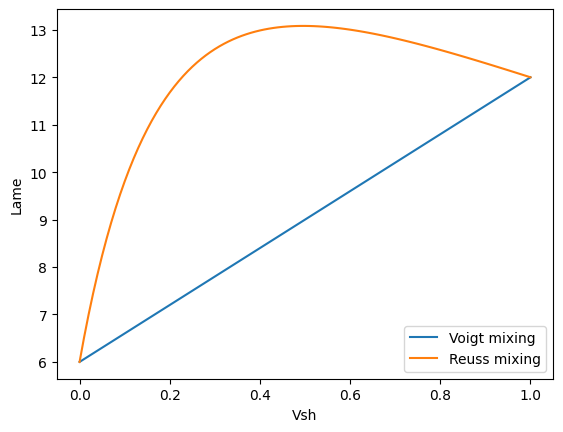

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from rokpy.materials import Mineral, ElasticPropertySet, MineralSet
from rokpy.models import BoundMethods


Vsh = np.linspace(0,1,101)
Vqz = 1-Vsh
shale = Mineral(ElasticPropertySet(2.1,20,12),'Shale')
quartz = Mineral(ElasticPropertySet(2.6,36,45),'Quartz')

voigt_mineralset = MineralSet({shale:Vsh, quartz:Vqz}, BoundMethods.MixingMethodName.VoigtReussHill, upper_weight=1) #upper_weight=1 : Voigt bound
reuss_mineralset = MineralSet({shale:Vsh, quartz:Vqz}, BoundMethods.MixingMethodName.VoigtReussHill, upper_weight=0) #upper_weight=0 : Reuss bound

plt.plot(Vsh,voigt_mineralset.lame, Vsh,reuss_mineralset.lame)
plt.legend(["Voigt mixing", "Reuss mixing"])
plt.xlabel("Vsh")
plt.ylabel("Lame")
plt.show()

## FluidSet Definition
As described earlier, as `FluidSet` and `MineralSet` are two subclasses of `ComponentSet`, they are very similar in terms of functionalities.

In [17]:
from rokpy.materials import Fluid, FluidSet
from rokpy.constants import FluidsPropertyTable


# Define The Fluid sets and modify them if needed
T = 80
P = 20
salinity = 70000
api = 30
gor = 1
solution_gas_gravity = 0.6
free_gas_gravity = 0.6

fluid_props = FluidsPropertyTable()
fluid_props.calculate(T, P, salinity, api, gor, solution_gas_gravity, free_gas_gravity)


brine = Fluid(fluid_props.Brine)
oil = Fluid(fluid_props.Oil)
gas = Fluid(fluid_props.Gas)

fluidset = FluidSet({brine:0.9, oil:0.1})
print(fluidset)

print('PoreFluid Saturations are normalized by default:')
print(fluidset.fractions)

#Modify a Fluid in fluidset
fluid_props.Oil.density = 0.95
print('Dynamic behaviour of PoreFluid when a component is modified:')
print(fluidset)

#Add a Fluid to fluidset
fluidset.add_component(gas, 0.1, isproportion = False)
print('PoreFluid properties once a fluid is added:')
print(fluidset)

#Remove a Fluid from fluidset
fluidset.remove_component(oil)
print('PoreFluid properties once a fluid is removed:')
print(fluidset)

Type                |   Fraction    |    Density    |  P-velocity   |  S-velocity   |     Bulk      |     Shear     |    Poisson    
----------------------------------------------------------------------------------------------------------------------------------
Brine               |    0.9000     |     1.030     |    1654.29    |     0.00      |     2.82      |     0.00      |     0.500     
Oil                 |    0.1000     |     0.798     |    1253.14    |     0.00      |     1.25      |     0.00      |     0.500     
----------------------------------------------------------------------------------------------------------------------------------
FluidSet            |     1.000     |     1.007     |    1577.60    |     0.00      |     2.51      |     0.00      |     0.500     

PoreFluid Saturations are normalized by default:
[array([0.9]), array([0.1])]
Dynamic behaviour of PoreFluid when a component is modified:
Type                |   Fraction    |    Density    |  P-velocity 

In following example we inspect how the effective P-wave velocity of a Quartz-Water mixture varies as a function of porosity and ComponentSet's `upper_weight`:

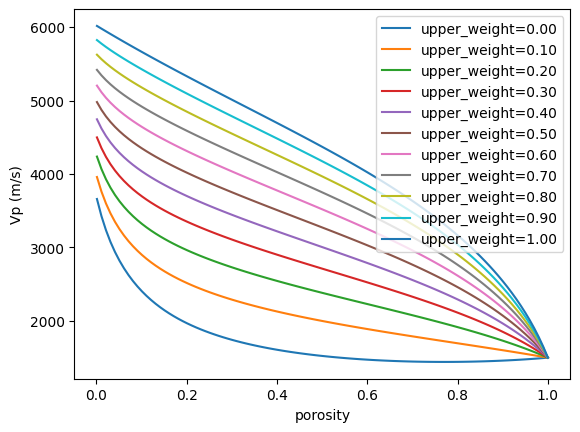

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from rokpy.materials import Mineral, Fluid, ElasticPropertySet, MineralSet, ComponentSet
from rokpy.effective_medium import BoundMethods

porosity = np.linspace(0.001,1,101)
Water = Fluid(ElasticPropertySet(1, 2.25, 0))
quartz = Mineral(ElasticPropertySet(2.65, 36, 45))

mineralset = ComponentSet({quartz: 1-porosity, Water: porosity}, BoundMethods.MixingMethodName.HashinShtrikmanWalpole)

plt.figure()
legend = []
for weight in np.linspace(0,1,11):
    mineralset.upper_weight = weight
    plt.plot(porosity, mineralset.p_velocity)
    legend.append(f'upper_weight={weight:3.2f}')
plt.legend(legend)
plt.xlabel("porosity")
plt.ylabel("Vp (m/s)")
plt.show()